# Nexus Mods Rewards Data Analysis

This notebook parses, cleans, and analyzes Nexus Mods rewards data from raw text format.
It includes data cleaning, statistical analysis, trend analysis, forecasting, outlier detection, and comprehensive visualizations.

## 1. Import Required Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime, timedelta
from typing import List, Tuple, Optional
import os
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Create output directory
output_dir = 'analysis_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}")
else:
    print(f"Using existing output directory: {output_dir}")

Using existing output directory: analysis_output


## 2. Define Reusable Functions

In [22]:
def parse_nexusmods_data(file_path: str) -> pd.DataFrame:
    """
    Parse and clean Nexus Mods rewards data from raw text file.
    
    Handles two data formats:
    - Format 1: Month Year - Downloads DP Rewards DP View Report
    - Format 2: Month Year ExtraNum Downloads DP Rewards DP View Report
    
    Parameters:
    -----------
    file_path : str
        Path to the raw text file containing the data
    
    Returns:
    --------
    pd.DataFrame
        Clean DataFrame with Month, Unique Downloads, and Mod Rewards columns
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    data_lines = [line.strip() for line in lines if line.strip() and not line.strip().startswith('Month')]
    parsed_data = []
    
    for line in data_lines:
        line = re.sub(r'^\s*\d+\s*\|', '', line).strip()
        if not line:
            continue
        
        line = line.replace('View Report', '')
        parts = line.split()
        
        if len(parts) < 4:
            continue
        
        try:
            month, year = parts[0], parts[1]
            date_obj = datetime.strptime(f"{month} {year}", '%b %Y')
            
            # Remove dash if present and collect all numeric values
            numeric_values = []
            for part in parts[2:]:
                # Remove dash if it's a standalone element
                if part == '-':
                    continue
                cleaned = part.replace(',', '').replace('DP', '')
                if cleaned.replace('-', '').replace('.', '').isdigit():
                    numeric_values.append(int(cleaned))
            
            if len(numeric_values) >= 2:
                unique_downloads, mod_rewards = numeric_values[-2], numeric_values[-1]
            elif len(numeric_values) == 1:
                unique_downloads, mod_rewards = numeric_values[0], 0
            else:
                continue
            
            parsed_data.append({
                'Month': date_obj,
                'Unique Downloads': unique_downloads,
                'Mod Rewards': mod_rewards
            })
        except (ValueError, IndexError) as e:
            print(f"Error parsing line: {line}")
            print(f"Error: {e}")
            continue
    
    df = pd.DataFrame(parsed_data)
    df = df.sort_values('Month').reset_index(drop=True)
    df.set_index('Month', inplace=True)
    return df


def detect_outliers_iqr(data: pd.Series) -> pd.Series:
    """
    Detect outliers using the IQR method.
    
    Parameters:
    -----------
    data : pd.Series
        Data series to analyze
    
    Returns:
    --------
    pd.Series
        Boolean series indicating outliers (True = outlier)
    """
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)


def detect_outliers_zscore(data: pd.Series, threshold: float = 3.0) -> pd.Series:
    """
    Detect outliers using the Z-score method.
    
    Parameters:
    -----------
    data : pd.Series
        Data series to analyze
    threshold : float
        Z-score threshold (default: 3.0)
    
    Returns:
    --------
    pd.Series
        Boolean series indicating outliers (True = outlier)
    """
    z_scores = np.abs(stats.zscore(data))
    return z_scores > threshold


def forecast_linear_trend(data: pd.Series, periods: int = 6) -> Tuple[pd.Series, pd.Series, pd.Series]:
    """
    Forecast future values using linear trend extrapolation.
    
    Parameters:
    -----------
    data : pd.Series
        Historical data series
    periods : int
        Number of periods to forecast
    
    Returns:
    --------
    Tuple[pd.Series, pd.Series, pd.Series]
        (forecast_dates, forecast_values, confidence_intervals)
    """
    x = np.arange(len(data))
    y = data.values
    
    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Generate forecast
    x_forecast = np.arange(len(data), len(data) + periods)
    forecast_values = slope * x_forecast + intercept
    
    # Calculate confidence intervals (95%)
    confidence = 1.96 * std_err * np.sqrt(1 + 1/len(data) + (x_forecast - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    lower_bound = forecast_values - confidence
    upper_bound = forecast_values + confidence
    
    # Generate forecast dates
    last_date = data.index[-1]
    forecast_dates = pd.date_range(start=data.index[-1] + pd.DateOffset(months=1), periods=periods, freq='MS')
    
    return forecast_dates, pd.Series(forecast_values, index=forecast_dates), \
           pd.DataFrame({'lower': lower_bound, 'upper': upper_bound}, index=forecast_dates)


def forecast_moving_average(data: pd.Series, window: int = 3, periods: int = 6) -> Tuple[pd.Series, pd.Series]:
    """
    Forecast future values using moving average.
    
    Parameters:
    -----------
    data : pd.Series
        Historical data series
    window : int
        Moving average window size
    periods : int
        Number of periods to forecast
    
    Returns:
    --------
    Tuple[pd.Series, pd.Series]
        (forecast_dates, forecast_values)
    """
    forecast_values = []
    extended_data = data.copy().tolist()
    
    for _ in range(periods):
        next_value = np.mean(extended_data[-window:])
        extended_data.append(next_value)
        forecast_values.append(next_value)
    
    forecast_dates = pd.date_range(start=data.index[-1] + timedelta(days=32), 
                                  periods=periods, freq='MS')
    
    return forecast_dates, pd.Series(forecast_values, index=forecast_dates)


def create_time_series_plot(df: pd.DataFrame, columns: List[str], title: str, 
                          ylabel: str, colors: List[str], 
                          show_moving_avg: bool = False,
                          show_outliers: bool = False,
                          outlier_mask: Optional[pd.Series] = None):
    """
    Create a time series plot with optional moving averages and outliers.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data to plot
    columns : List[str]
        Columns to plot
    title : str
        Plot title
    ylabel : str
        Y-axis label
    colors : List[str]
        Colors for each column
    show_moving_avg : bool
        Whether to show moving averages
    show_outliers : bool
        Whether to highlight outliers
    outlier_mask : Optional[pd.Series]
        Boolean mask for outliers
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    
    for i, col in enumerate(columns):
        ax.plot(df.index, df[col], marker='o', linewidth=2, 
                markersize=5, label=col, color=colors[i], alpha=0.7)
        
        if show_moving_avg and f'{col} MA_3' in df.columns:
            ax.plot(df.index, df[f'{col} MA_3'], linewidth=2.5, 
                    label=f'{col} (3-month MA)', color=colors[i], linestyle='--', alpha=0.8)
        
        if show_outliers and outlier_mask is not None:
            outlier_dates = df.index[outlier_mask]
            outlier_values = df.loc[outlier_mask, col]
            ax.scatter(outlier_dates, outlier_values, s=200, 
                      color='red', marker='*', label='Outliers', zorder=5, edgecolors='black')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    return fig, ax


def create_forecast_plot(historical_data: pd.Series, forecast_dates: pd.Series, 
                      forecast_values: pd.Series, confidence_intervals: pd.DataFrame,
                      title: str, ylabel: str, color: str):
    """
    Create a forecast plot with confidence intervals.
    
    Parameters:
    -----------
    historical_data : pd.Series
        Historical data
    forecast_dates : pd.Series
        Forecast dates
    forecast_values : pd.Series
        Forecast values
    confidence_intervals : pd.DataFrame
        Confidence interval bounds
    title : str
        Plot title
    ylabel : str
        Y-axis label
    color : str
        Line color
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Plot historical data
    ax.plot(historical_data.index, historical_data, marker='o', 
            linewidth=2, markersize=5, label='Historical', color=color, alpha=0.7)
    
    # Plot forecast
    ax.plot(forecast_dates, forecast_values, marker='s', 
            linewidth=2.5, markersize=6, label='Forecast', color=color, linestyle='--')
    
    # Plot confidence intervals
    ax.fill_between(forecast_dates, confidence_intervals['lower'], 
                  confidence_intervals['upper'], alpha=0.2, color=color, 
                  label='95% Confidence Interval')
    
    # Add vertical line at forecast start
    ax.axvline(x=historical_data.index[-1], color='red', 
                linestyle=':', linewidth=2, label='Forecast Start')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    return fig, ax


print("Reusable functions defined successfully!")

Reusable functions defined successfully!


## 3. Load and Clean the Data

In [23]:
# Load the data
file_path = 'Month Unique Downloads Mod Rewards Your.txt'
df = parse_nexusmods_data(file_path)

# Display the first few rows
print("Data Shape:", df.shape)
print("\nFirst 10 rows:")
print(df.head(10))
print("\nLast 10 rows:")
print(df.tail(10))

Data Shape: (62, 2)

First 10 rows:
            Unique Downloads  Mod Rewards
Month                                    
2020-10-01               327          327
2020-11-01              2780         2780
2020-12-01              7896         5609
2021-01-01              9166         7898
2021-02-01             11253         9865
2021-03-01             13658        12609
2021-04-01             17723        15653
2021-05-01             15074        12984
2021-06-01             16633        15002
2021-07-01             20955        19021

Last 10 rows:
            Unique Downloads  Mod Rewards
Month                                    
2025-02-01             59790        59701
2025-03-01             52050        51910
2025-04-01             55143        54991
2025-05-01             54348        54196
2025-06-01             44106        43970
2025-07-01             33149        33037
2025-08-01             31906        31854
2025-09-01             33281        33224
2025-10-01             38

## 4. Calculate Rolling Statistics and Growth Rates

In [24]:
# Calculate moving averages
df['Downloads MA_3'] = df['Unique Downloads'].rolling(window=3, min_periods=1).mean()
df['Downloads MA_6'] = df['Unique Downloads'].rolling(window=6, min_periods=1).mean()
df['Rewards MA_3'] = df['Mod Rewards'].rolling(window=3, min_periods=1).mean()
df['Rewards MA_6'] = df['Mod Rewards'].rolling(window=6, min_periods=1).mean()

# Calculate rolling standard deviation
df['Downloads Std_3'] = df['Unique Downloads'].rolling(window=3, min_periods=1).std()
df['Rewards Std_3'] = df['Mod Rewards'].rolling(window=3, min_periods=1).std()

# Calculate growth rates
df['Downloads Growth %'] = df['Unique Downloads'].pct_change() * 100
df['Rewards Growth %'] = df['Mod Rewards'].pct_change() * 100

# Calculate cumulative totals
df['Cumulative Downloads'] = df['Unique Downloads'].cumsum()
df['Cumulative Rewards'] = df['Mod Rewards'].cumsum()

# Add year and quarter columns
df['Year'] = df.index.year
df['Quarter'] = df.index.quarter
df['Month_Name'] = df.index.strftime('%B')
df['Month_Num'] = df.index.month

# Display first few rows with new columns
print("\nData with Rolling Statistics (first 10 rows):")
print(df[['Unique Downloads', 'Downloads MA_3', 'Downloads MA_6', 
          'Mod Rewards', 'Rewards MA_3', 'Rewards MA_6']].head(10))


Data with Rolling Statistics (first 10 rows):
            Unique Downloads  Downloads MA_3  Downloads MA_6  Mod Rewards  \
Month                                                                       
2020-10-01               327          327.00          327.00          327   
2020-11-01              2780        1,553.50        1,553.50         2780   
2020-12-01              7896        3,667.67        3,667.67         5609   
2021-01-01              9166        6,614.00        5,042.25         7898   
2021-02-01             11253        9,438.33        6,284.40         9865   
2021-03-01             13658       11,359.00        7,513.33        12609   
2021-04-01             17723       14,211.33       10,412.67        15653   
2021-05-01             15074       15,485.00       12,461.67        12984   
2021-06-01             16633       16,476.67       13,917.83        15002   
2021-07-01             20955       17,554.00       15,882.67        19021   

            Rewards MA_3  Re

## 5. Outlier Detection

In [25]:
# Detect outliers using IQR method
df['Downloads Outlier_IQR'] = detect_outliers_iqr(df['Unique Downloads'])
df['Rewards Outlier_IQR'] = detect_outliers_iqr(df['Mod Rewards'])

# Detect outliers using Z-score method
df['Downloads Outlier_ZScore'] = detect_outliers_zscore(df['Unique Downloads'], threshold=3.0)
df['Rewards Outlier_ZScore'] = detect_outliers_zscore(df['Mod Rewards'], threshold=3.0)

# Combined outlier detection (either method)
df['Downloads Outlier'] = df['Downloads Outlier_IQR'] | df['Downloads Outlier_ZScore']
df['Rewards Outlier'] = df['Rewards Outlier_IQR'] | df['Rewards Outlier_ZScore']

# Print outlier summary
print("\n" + "="*70)
print("OUTLIER DETECTION SUMMARY")
print("="*70)
print(f"\nDownloads Outliers (IQR method): {df['Downloads Outlier_IQR'].sum()} months")
print(f"Downloads Outliers (Z-score method): {df['Downloads Outlier_ZScore'].sum()} months")
print(f"Downloads Outliers (combined): {df['Downloads Outlier'].sum()} months")
print(f"\nRewards Outliers (IQR method): {df['Rewards Outlier_IQR'].sum()} months")
print(f"Rewards Outliers (Z-score method): {df['Rewards Outlier_ZScore'].sum()} months")
print(f"Rewards Outliers (combined): {df['Rewards Outlier'].sum()} months")

# Show outlier months
if df['Downloads Outlier'].any():
    print("\nDownloads Outlier Months:")
    outlier_months = df[df['Downloads Outlier']][['Unique Downloads', 'Downloads Growth %']]
    outlier_months['Month'] = outlier_months.index.strftime('%B %Y')
    print(outlier_months[['Month', 'Unique Downloads', 'Downloads Growth %']].to_string(index=False))

if df['Rewards Outlier'].any():
    print("\nRewards Outlier Months:")
    outlier_months = df[df['Rewards Outlier']][['Mod Rewards', 'Rewards Growth %']]
    outlier_months['Month'] = outlier_months.index.strftime('%B %Y')
    print(outlier_months[['Month', 'Mod Rewards', 'Rewards Growth %']].to_string(index=False))


OUTLIER DETECTION SUMMARY

Downloads Outliers (IQR method): 4 months
Downloads Outliers (Z-score method): 0 months
Downloads Outliers (combined): 4 months

Rewards Outliers (IQR method): 4 months
Rewards Outliers (Z-score method): 0 months
Rewards Outliers (combined): 4 months

Downloads Outlier Months:
        Month  Unique Downloads  Downloads Growth %
 October 2023            115350               86.65
November 2023            117985                2.28
December 2023            113373               -3.91
 January 2024            105503               -6.94

Rewards Outlier Months:
        Month  Mod Rewards  Rewards Growth %
 October 2023       114934             87.84
November 2023       117424              2.17
December 2023       112906             -3.85
 January 2024       104948             -7.05


## 6. Predictive Forecasting

In [26]:
# Generate forecasts using linear trend
forecast_periods = 6

# Downloads forecast
dl_forecast_dates, dl_forecast_values, dl_confidence = forecast_linear_trend(
    df['Unique Downloads'], periods=forecast_periods
)

# Rewards forecast
rw_forecast_dates, rw_forecast_values, rw_confidence = forecast_linear_trend(
    df['Mod Rewards'], periods=forecast_periods
)

# Moving average forecast
dl_ma_dates, dl_ma_forecast = forecast_moving_average(
    df['Unique Downloads'], window=3, periods=forecast_periods
)
rw_ma_dates, rw_ma_forecast = forecast_moving_average(
    df['Mod Rewards'], window=3, periods=forecast_periods
)

print("\n" + "="*70)
print("FORECAST SUMMARY")
print("="*70)
print(f"\nForecasting {forecast_periods} months ahead from {df.index[-1].strftime('%B %Y')}")
print(f"\nDownloads Forecast (Linear Trend):")
for i in range(forecast_periods):
    date = dl_forecast_dates[i]
    value = dl_forecast_values.iloc[i]
    lower = dl_confidence['lower'].iloc[i]
    upper = dl_confidence['upper'].iloc[i]
    print(f"  {date.strftime('%B %Y')}: {value:,.0f} (95% CI: {lower:,.0f} - {upper:,.0f})")

print(f"\nRewards Forecast (Linear Trend):")
for i in range(forecast_periods):
    date = rw_forecast_dates[i]
    value = rw_forecast_values.iloc[i]
    lower = rw_confidence['lower'].iloc[i]
    upper = rw_confidence['upper'].iloc[i]
    print(f"  {date.strftime('%B %Y')}: {value:,.0f} (95% CI: {lower:,.0f} - {upper:,.0f})")


FORECAST SUMMARY

Forecasting 6 months ahead from November 2025

Downloads Forecast (Linear Trend):
  December 2025: 70,219 (95% CI: 69,897 - 70,541)
  January 2026: 70,984 (95% CI: 70,662 - 71,306)
  February 2026: 71,749 (95% CI: 71,426 - 72,072)
  March 2026: 72,515 (95% CI: 72,191 - 72,838)
  April 2026: 73,280 (95% CI: 72,956 - 73,604)
  May 2026: 74,046 (95% CI: 73,721 - 74,370)

Rewards Forecast (Linear Trend):
  December 2025: 70,362 (95% CI: 70,042 - 70,683)
  January 2026: 71,172 (95% CI: 70,851 - 71,493)
  February 2026: 71,982 (95% CI: 71,661 - 72,303)
  March 2026: 72,792 (95% CI: 72,470 - 73,114)
  April 2026: 73,602 (95% CI: 73,279 - 73,924)
  May 2026: 74,412 (95% CI: 74,089 - 74,734)


## 7. Statistical Summary

In [27]:
# Calculate key statistics (once, for reuse)
total_rewards = df['Mod Rewards'].sum()
total_downloads = df['Unique Downloads'].sum()
mean_downloads = df['Unique Downloads'].mean()
median_downloads = df['Unique Downloads'].median()
std_downloads = df['Unique Downloads'].std()
mean_rewards = df['Mod Rewards'].mean()
median_rewards = df['Mod Rewards'].median()
std_rewards = df['Mod Rewards'].std()

# Peak performance
peak_downloads_month = df['Unique Downloads'].idxmax()
peak_downloads_value = df['Unique Downloads'].max()
peak_rewards_month = df['Mod Rewards'].idxmax()
peak_rewards_value = df['Mod Rewards'].max()
lowest_downloads_month = df['Unique Downloads'].idxmin()
lowest_downloads_value = df['Unique Downloads'].min()

# Growth statistics
avg_monthly_growth_downloads = df['Downloads Growth %'].mean()
avg_monthly_growth_rewards = df['Rewards Growth %'].mean()

# Correlation
correlation = df['Unique Downloads'].corr(df['Mod Rewards'])

# Display statistical summary
print("="*70)
print("NEXUS MODS REWARDS - STATISTICAL SUMMARY")
print("="*70)
print(f"\nData Period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Total Months: {len(df)}")
print()
print("--- TOTALS ---")
print(f"Total Mod Rewards: {total_rewards:,} points")
print(f"Total Unique Downloads: {total_downloads:,}")
print()
print("--- DOWNLOADS STATISTICS ---")
print(f"Mean Unique Downloads: {mean_downloads:,.2f}")
print(f"Median Unique Downloads: {median_downloads:,.2f}")
print(f"Std Dev of Downloads: {std_downloads:,.2f}")
print(f"Coefficient of Variation: {(std_downloads/mean_downloads)*100:.2f}%")
print()
print("--- REWARDS STATISTICS ---")
print(f"Mean Mod Rewards: {mean_rewards:,.2f}")
print(f"Median Mod Rewards: {median_rewards:,.2f}")
print(f"Std Dev of Rewards: {std_rewards:,.2f}")
print(f"Coefficient of Variation: {(std_rewards/mean_rewards)*100:.2f}%")
print()
print("--- PEAK PERFORMANCE ---")
print(f"Peak Downloads Month: {peak_downloads_month.strftime('%B %Y')}")
print(f"Peak Downloads Value: {peak_downloads_value:,}")
print()
print(f"Peak Rewards Month: {peak_rewards_month.strftime('%B %Y')}")
print(f"Peak Rewards Value: {peak_rewards_value:,}")
print()
print(f"Lowest Downloads Month: {lowest_downloads_month.strftime('%B %Y')}")
print(f"Lowest Downloads Value: {lowest_downloads_value:,}")
print()
print("--- GROWTH ANALYSIS ---")
print(f"Average Monthly Growth (Downloads): {avg_monthly_growth_downloads:.2f}%")
print(f"Average Monthly Growth (Rewards): {avg_monthly_growth_rewards:.2f}%")
print()
print("--- CORRELATION ---")
print(f"Downloads-Rewards Correlation: {correlation:.4f}")
print(f"Correlation Strength: {'Very Strong' if abs(correlation) > 0.8 else 'Strong' if abs(correlation) > 0.6 else 'Moderate' if abs(correlation) > 0.4 else 'Weak'}")
print("="*70)

NEXUS MODS REWARDS - STATISTICAL SUMMARY

Data Period: October 2020 to November 2025
Total Months: 62

--- TOTALS ---
Total Mod Rewards: 2,780,871 points
Total Unique Downloads: 2,858,686

--- DOWNLOADS STATISTICS ---
Mean Unique Downloads: 46,107.84
Median Unique Downloads: 43,277.50
Std Dev of Downloads: 26,173.13
Coefficient of Variation: 56.77%

--- REWARDS STATISTICS ---
Mean Mod Rewards: 44,852.76
Median Mod Rewards: 40,396.00
Std Dev of Rewards: 26,513.89
Coefficient of Variation: 59.11%

--- PEAK PERFORMANCE ---
Peak Downloads Month: November 2023
Peak Downloads Value: 117,985

Peak Rewards Month: November 2023
Peak Rewards Value: 117,424

Lowest Downloads Month: October 2020
Lowest Downloads Value: 327

--- GROWTH ANALYSIS ---
Average Monthly Growth (Downloads): 20.87%
Average Monthly Growth (Rewards): 20.26%

--- CORRELATION ---
Downloads-Rewards Correlation: 0.9990
Correlation Strength: Very Strong


## 8. Visualization: Time Series with Outliers

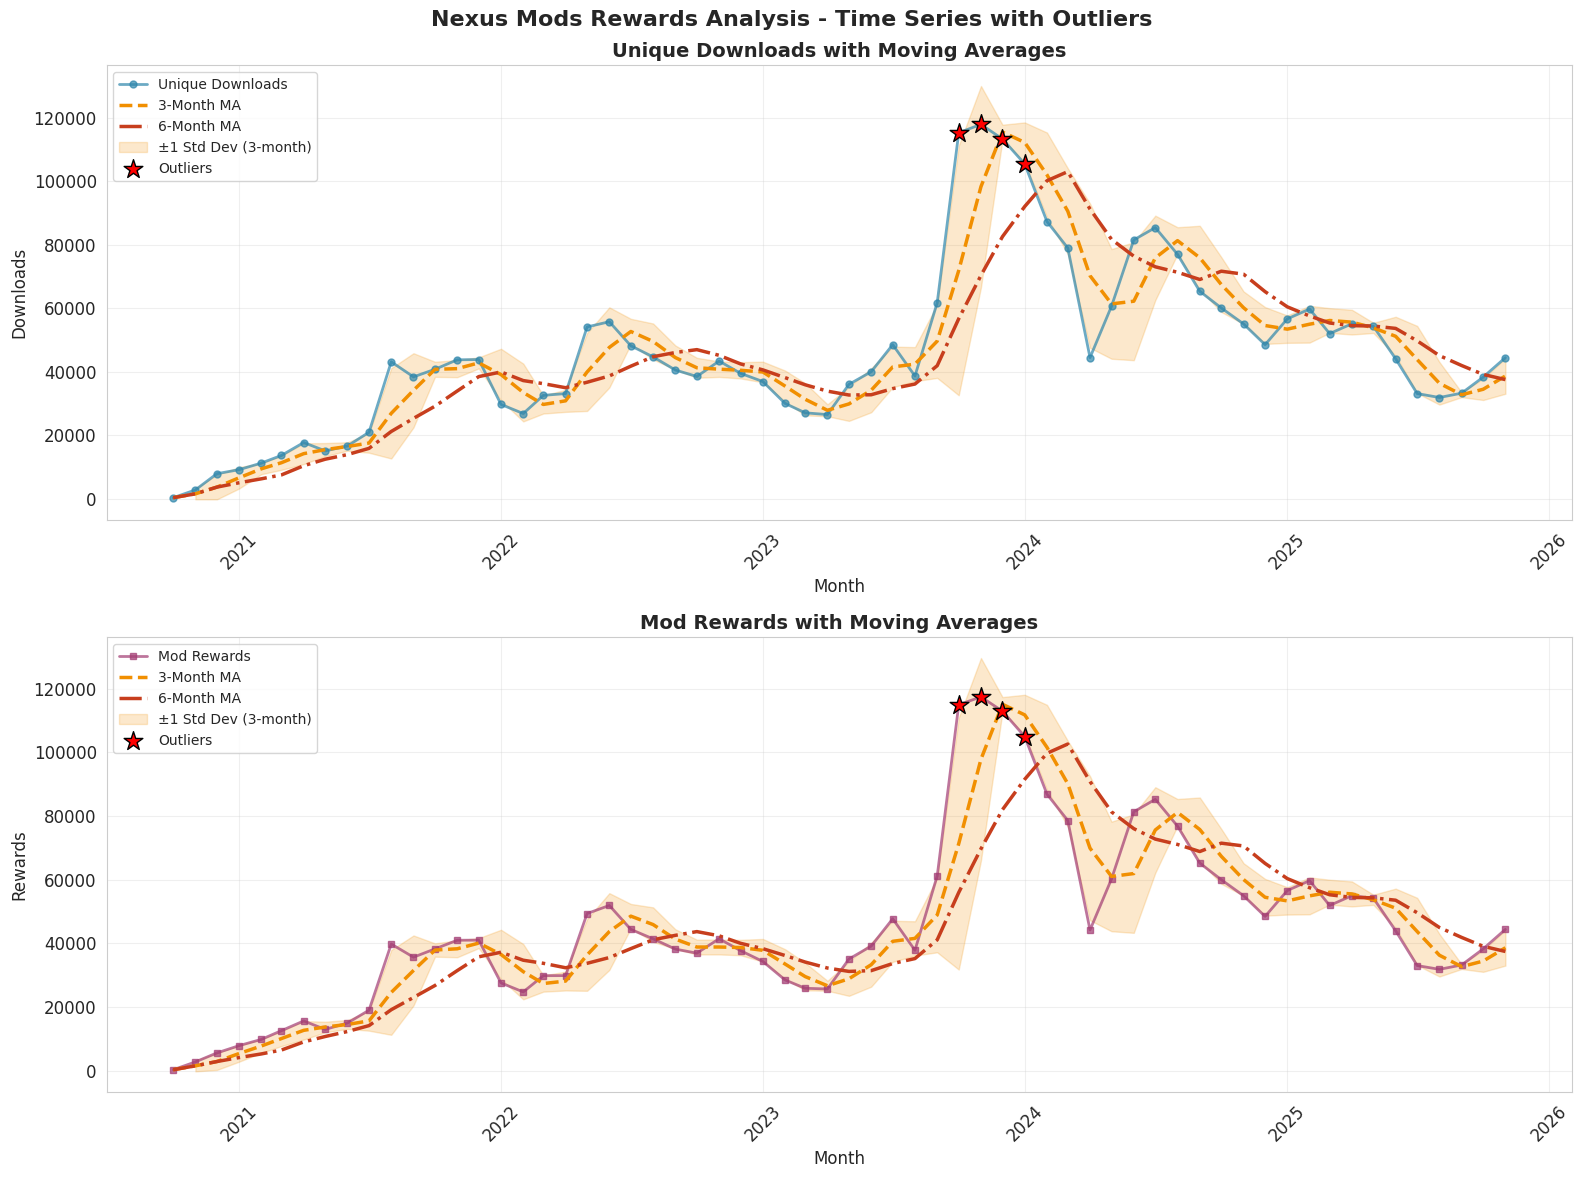


Visualization saved to: analysis_output/moving_averages_with_outliers.png


In [28]:
# Create time series plots with outliers highlighted
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Nexus Mods Rewards Analysis - Time Series with Outliers', 
             fontsize=16, fontweight='bold')

# Plot 1: Downloads with moving averages and outliers
ax1 = axes[0]
ax1.plot(df.index, df['Unique Downloads'], marker='o', linewidth=2, 
         markersize=5, label='Unique Downloads', color='#2E86AB', alpha=0.7)
ax1.plot(df.index, df['Downloads MA_3'], linewidth=2.5, 
         label='3-Month MA', color='#F18F01', linestyle='--')
ax1.plot(df.index, df['Downloads MA_6'], linewidth=2.5, 
         label='6-Month MA', color='#C73E1D', linestyle='-.')
ax1.fill_between(df.index, df['Downloads MA_3'] - df['Downloads Std_3'], 
                  df['Downloads MA_3'] + df['Downloads Std_3'], 
                  alpha=0.2, color='#F18F01', label='±1 Std Dev (3-month)')

# Highlight outliers
if df['Downloads Outlier'].any():
    outlier_dates = df.index[df['Downloads Outlier']]
    outlier_values = df.loc[df['Downloads Outlier'], 'Unique Downloads']
    ax1.scatter(outlier_dates, outlier_values, s=200, 
              color='red', marker='*', label='Outliers', zorder=5, edgecolors='black')

ax1.set_title('Unique Downloads with Moving Averages', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Downloads', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Rewards with moving averages and outliers
ax2 = axes[1]
ax2.plot(df.index, df['Mod Rewards'], marker='s', linewidth=2, 
         markersize=5, label='Mod Rewards', color='#A23B72', alpha=0.7)
ax2.plot(df.index, df['Rewards MA_3'], linewidth=2.5, 
         label='3-Month MA', color='#F18F01', linestyle='--')
ax2.plot(df.index, df['Rewards MA_6'], linewidth=2.5, 
         label='6-Month MA', color='#C73E1D', linestyle='-.')
ax2.fill_between(df.index, df['Rewards MA_3'] - df['Rewards Std_3'], 
                  df['Rewards MA_3'] + df['Rewards Std_3'], 
                  alpha=0.2, color='#F18F01', label='±1 Std Dev (3-month)')

# Highlight outliers
if df['Rewards Outlier'].any():
    outlier_dates = df.index[df['Rewards Outlier']]
    outlier_values = df.loc[df['Rewards Outlier'], 'Mod Rewards']
    ax2.scatter(outlier_dates, outlier_values, s=200, 
              color='red', marker='*', label='Outliers', zorder=5, edgecolors='black')

ax2.set_title('Mod Rewards with Moving Averages', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Rewards', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/moving_averages_with_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/moving_averages_with_outliers.png")

## 9. Forecasting Visualization

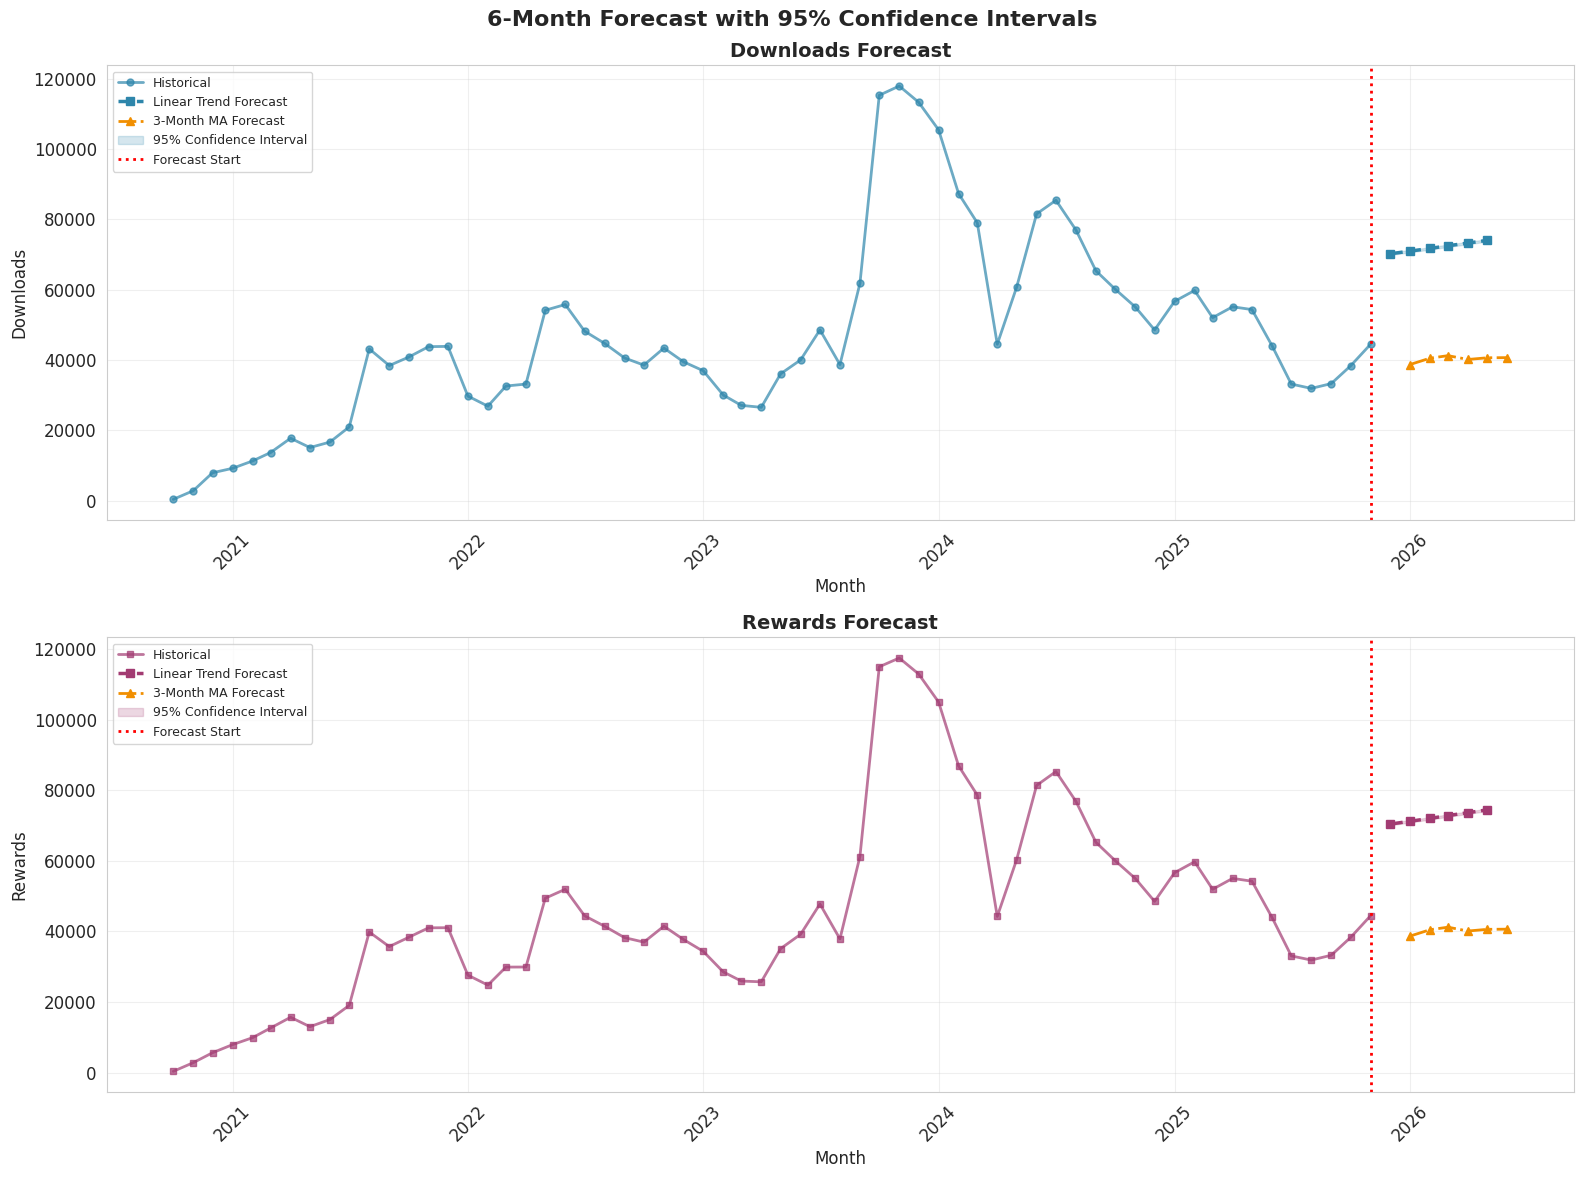


Visualization saved to: analysis_output/forecast_analysis.png


In [29]:
# Create forecast plots
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle(f'{forecast_periods}-Month Forecast with 95% Confidence Intervals', 
             fontsize=16, fontweight='bold')

# Plot 1: Downloads forecast
ax1 = axes[0]
ax1.plot(df.index, df['Unique Downloads'], marker='o', 
         linewidth=2, markersize=5, label='Historical', color='#2E86AB', alpha=0.7)
ax1.plot(dl_forecast_dates, dl_forecast_values, marker='s', 
         linewidth=2.5, markersize=6, label='Linear Trend Forecast', 
         color='#2E86AB', linestyle='--')
ax1.plot(dl_ma_dates, dl_ma_forecast, marker='^', 
         linewidth=2, markersize=6, label='3-Month MA Forecast', 
         color='#F18F01', linestyle='-.')
ax1.fill_between(dl_forecast_dates, dl_confidence['lower'], 
                  dl_confidence['upper'], alpha=0.2, color='#2E86AB', 
                  label='95% Confidence Interval')
ax1.axvline(x=df.index[-1], color='red', linestyle=':', 
            linewidth=2, label='Forecast Start')
ax1.set_title('Downloads Forecast', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Downloads', fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Rewards forecast
ax2 = axes[1]
ax2.plot(df.index, df['Mod Rewards'], marker='s', 
         linewidth=2, markersize=5, label='Historical', color='#A23B72', alpha=0.7)
ax2.plot(rw_forecast_dates, rw_forecast_values, marker='s', 
         linewidth=2.5, markersize=6, label='Linear Trend Forecast', 
         color='#A23B72', linestyle='--')
ax2.plot(rw_ma_dates, rw_ma_forecast, marker='^', 
         linewidth=2, markersize=6, label='3-Month MA Forecast', 
         color='#F18F01', linestyle='-.')
ax2.fill_between(rw_forecast_dates, rw_confidence['lower'], 
                  rw_confidence['upper'], alpha=0.2, color='#A23B72', 
                  label='95% Confidence Interval')
ax2.axvline(x=df.index[-1], color='red', linestyle=':', 
            linewidth=2, label='Forecast Start')
ax2.set_title('Rewards Forecast', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Rewards', fontsize=12)
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/forecast_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/forecast_analysis.png")

## 10. Growth Rate Analysis

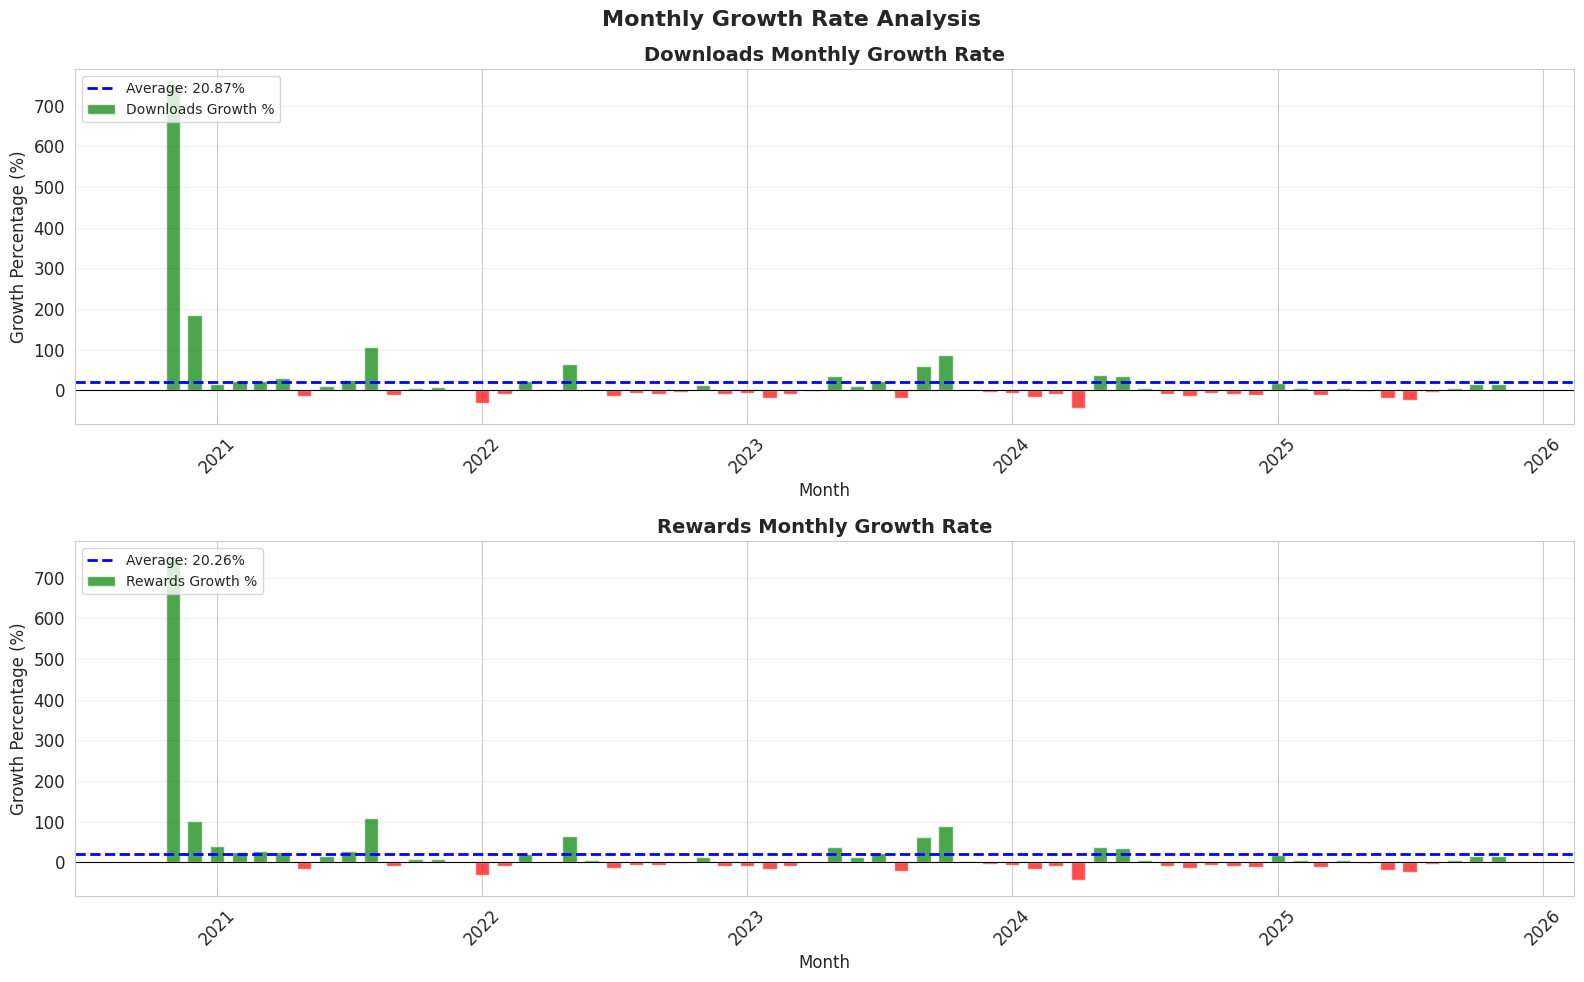


Visualization saved to: analysis_output/growth_rates.png


In [30]:
# Create growth rate visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Monthly Growth Rate Analysis', fontsize=16, fontweight='bold')

# Plot 1: Growth rates over time
ax1 = axes[0]
colors = ['green' if x >= 0 else 'red' for x in df['Downloads Growth %'].fillna(0)]
ax1.bar(df.index, df['Downloads Growth %'].fillna(0), width=20, 
        alpha=0.7, label='Downloads Growth %', color=colors)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.axhline(y=df['Downloads Growth %'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Average: {df["Downloads Growth %"].mean():.2f}%')
ax1.set_title('Downloads Monthly Growth Rate', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Growth Percentage (%)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Rewards growth rates
ax2 = axes[1]
colors = ['green' if x >= 0 else 'red' for x in df['Rewards Growth %'].fillna(0)]
ax2.bar(df.index, df['Rewards Growth %'].fillna(0), width=20, 
        alpha=0.7, label='Rewards Growth %', color=colors)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.axhline(y=df['Rewards Growth %'].mean(), color='blue', linestyle='--', 
            linewidth=2, label=f'Average: {df["Rewards Growth %"].mean():.2f}%')
ax2.set_title('Rewards Monthly Growth Rate', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Growth Percentage (%)', fontsize=12)
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/growth_rates.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/growth_rates.png")

## 11. Correlation and Scatter Analysis

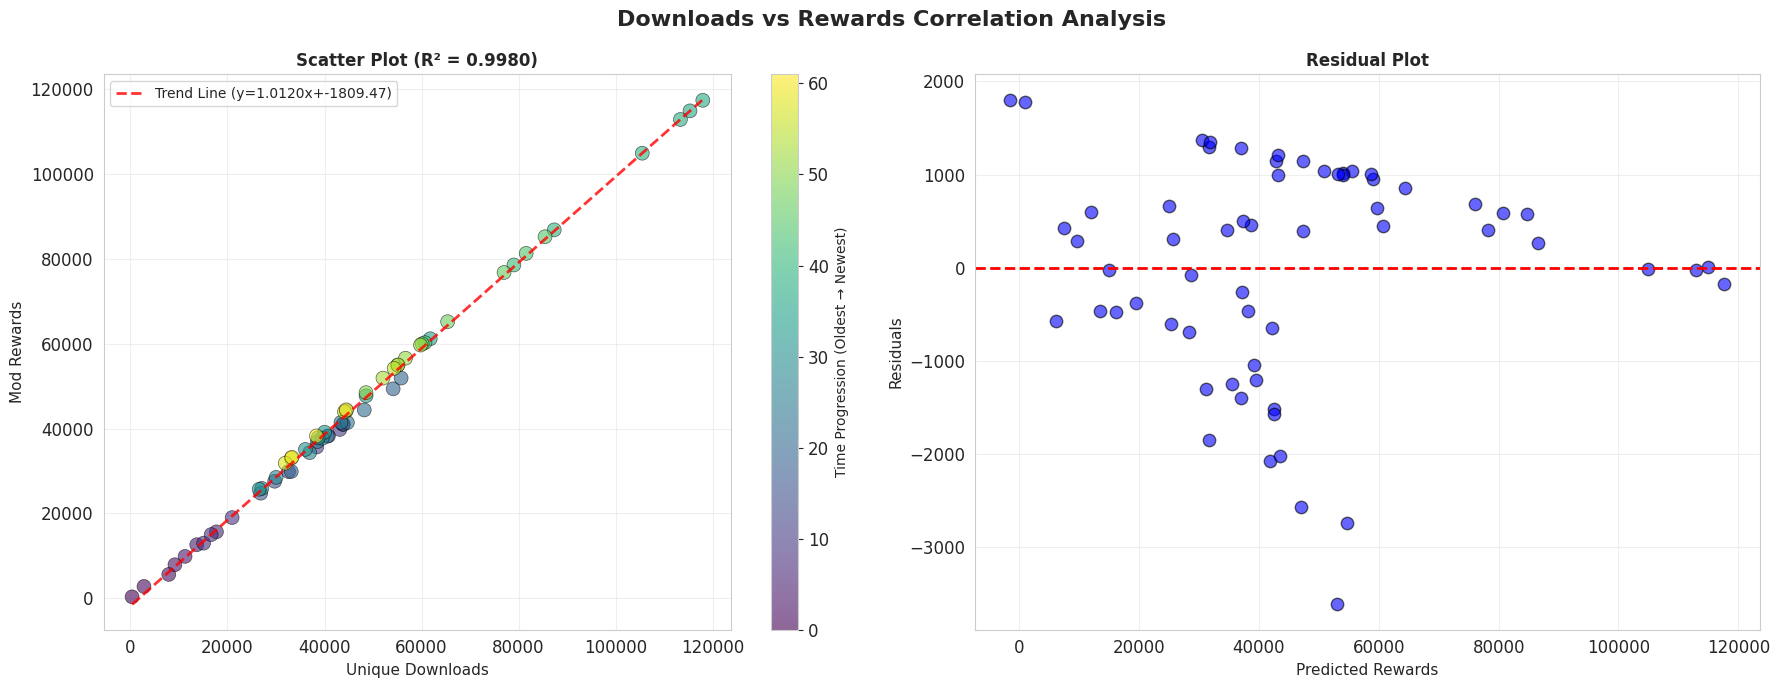


Visualization saved to: analysis_output/correlation_analysis.png


In [31]:
# Create scatter plot with detailed analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Downloads vs Rewards Correlation Analysis', fontsize=16, fontweight='bold')

# Plot 1: Scatter plot with trend line
ax1 = axes[0]
scatter = ax1.scatter(df['Unique Downloads'], df['Mod Rewards'], 
                      c=range(len(df)), cmap='viridis', s=100, alpha=0.6, 
                      edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(df['Unique Downloads'], df['Mod Rewards'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Unique Downloads'].min(), df['Unique Downloads'].max(), 100)
ax1.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, 
         label=f'Trend Line (y={z[0]:.4f}x+{z[1]:.2f})')

# Add R-squared
y_pred = p(df['Unique Downloads'])
y_actual = df['Mod Rewards']
ss_res = np.sum((y_actual - y_pred) ** 2)
ss_tot = np.sum((y_actual - np.mean(y_actual)) ** 2)
r_squared = 1 - (ss_res / ss_tot)

ax1.set_title(f'Scatter Plot (R² = {r_squared:.4f})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Unique Downloads', fontsize=11)
ax1.set_ylabel('Mod Rewards', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# Add colorbar to show time progression
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Time Progression (Oldest → Newest)', fontsize=10)

# Plot 2: Residual plot
ax2 = axes[1]
residuals = y_actual - y_pred
ax2.scatter(y_pred, residuals, alpha=0.6, color='blue', s=80, edgecolors='black')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted Rewards', fontsize=11)
ax2.set_ylabel('Residuals', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/correlation_analysis.png")

## 12. Seasonal Patterns Visualization

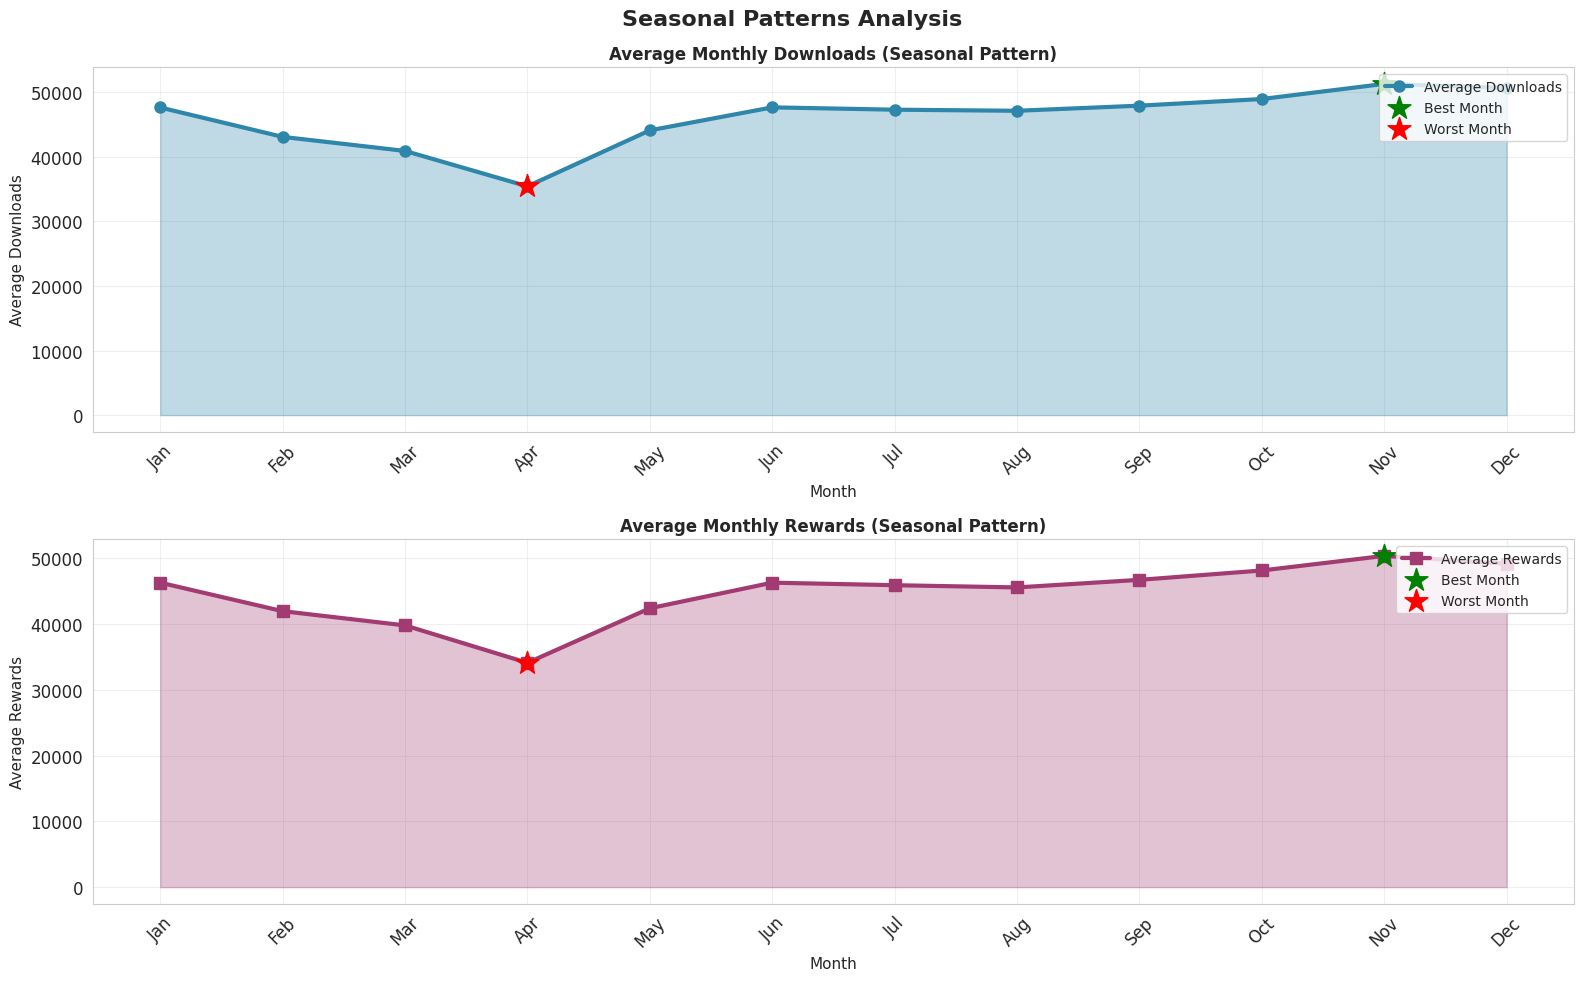


Visualization saved to: analysis_output/seasonal_patterns.png


In [32]:
# Monthly average across all years (seasonal patterns)
monthly_avg = df.groupby('Month_Num').agg({
    'Unique Downloads': 'mean',
    'Mod Rewards': 'mean'
}).round(2)

# Add month names
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']
monthly_avg['Month_Name'] = month_names

# Create seasonal patterns visualization
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Seasonal Patterns Analysis', fontsize=16, fontweight='bold')

# Plot 1: Monthly averages across all years
ax1 = axes[0]
x = range(1, 13)
ax1.plot(x, monthly_avg['Unique Downloads'], marker='o', linewidth=3, 
         markersize=8, label='Average Downloads', color='#2E86AB', 
         linestyle='-')
ax1.fill_between(x, monthly_avg['Unique Downloads'], alpha=0.3, color='#2E86AB')
ax1.set_xticks(x)
ax1.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax1.set_title('Average Monthly Downloads (Seasonal Pattern)', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Average Downloads', fontsize=11)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Highlight best and worst months
best_idx = monthly_avg['Unique Downloads'].idxmax()
worst_idx = monthly_avg['Unique Downloads'].idxmin()
ax1.scatter([best_idx], [monthly_avg.loc[best_idx, 'Unique Downloads']], 
            s=300, color='green', marker='*', label='Best Month', zorder=5)
ax1.scatter([worst_idx], [monthly_avg.loc[worst_idx, 'Unique Downloads']], 
            s=300, color='red', marker='*', label='Worst Month', zorder=5)
ax1.legend(loc='upper right', fontsize=10)

# Plot 2: Monthly rewards averages
ax2 = axes[1]
ax2.plot(x, monthly_avg['Mod Rewards'], marker='s', linewidth=3, 
         markersize=8, label='Average Rewards', color='#A23B72', 
         linestyle='-')
ax2.fill_between(x, monthly_avg['Mod Rewards'], alpha=0.3, color='#A23B72')
ax2.set_xticks(x)
ax2.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax2.set_title('Average Monthly Rewards (Seasonal Pattern)', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Average Rewards', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

# Highlight best and worst months
best_idx = monthly_avg['Mod Rewards'].idxmax()
worst_idx = monthly_avg['Mod Rewards'].idxmin()
ax2.scatter([best_idx], [monthly_avg.loc[best_idx, 'Mod Rewards']], 
            s=300, color='green', marker='*', label='Best Month', zorder=5)
ax2.scatter([worst_idx], [monthly_avg.loc[worst_idx, 'Mod Rewards']], 
            s=300, color='red', marker='*', label='Worst Month', zorder=5)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{output_dir}/seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/seasonal_patterns.png")

## 13. Year-over-Year Comparison

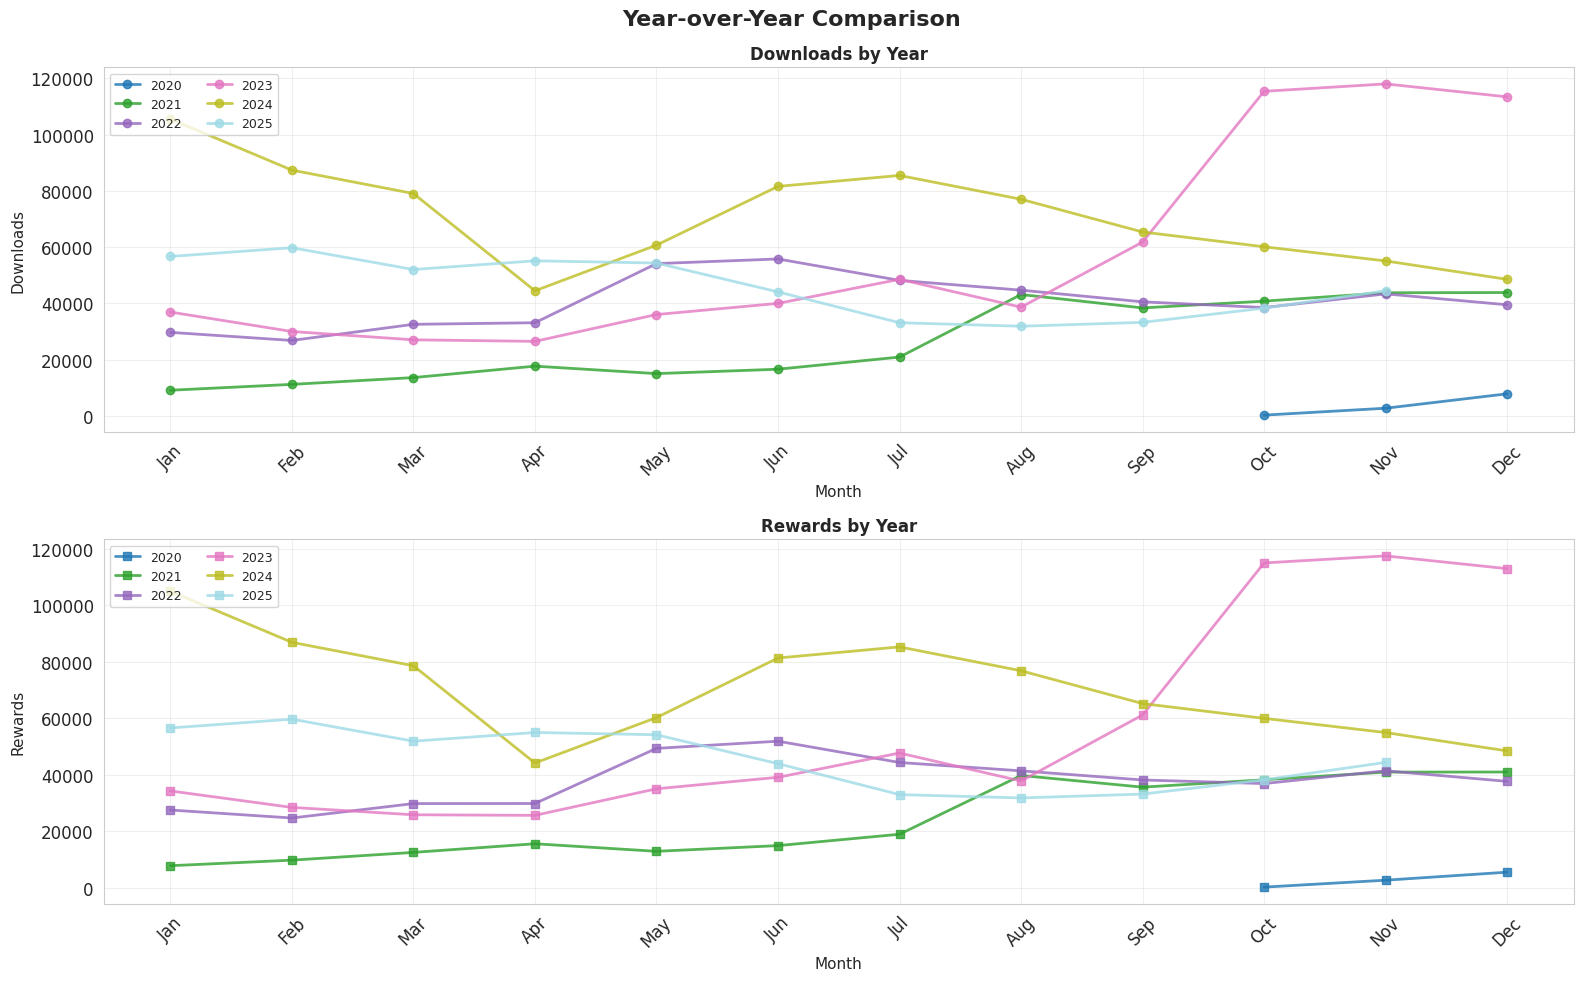


Visualization saved to: analysis_output/year_over_year.png


In [33]:
# Create year-over-year comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Year-over-Year Comparison', fontsize=16, fontweight='bold')

# Get unique years
years = df['Year'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(years)))

# Plot 1: Downloads by year
ax1 = axes[0]
for i, year in enumerate(sorted(years)):
    year_data = df[df['Year'] == year]
    ax1.plot(year_data.index.month, year_data['Unique Downloads'], 
             marker='o', linewidth=2, markersize=6, 
             label=f'{year}', color=colors[i], alpha=0.8)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax1.set_title('Downloads by Year', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Downloads', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)

# Plot 2: Rewards by year
ax2 = axes[1]
for i, year in enumerate(sorted(years)):
    year_data = df[df['Year'] == year]
    ax2.plot(year_data.index.month, year_data['Mod Rewards'], 
             marker='s', linewidth=2, markersize=6, 
             label=f'{year}', color=colors[i], alpha=0.8)

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([m[:3] for m in month_names], rotation=45)
ax2.set_title('Rewards by Year', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month', fontsize=11)
ax2.set_ylabel('Rewards', fontsize=11)
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/year_over_year.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/year_over_year.png")

## 14. Distribution Analysis

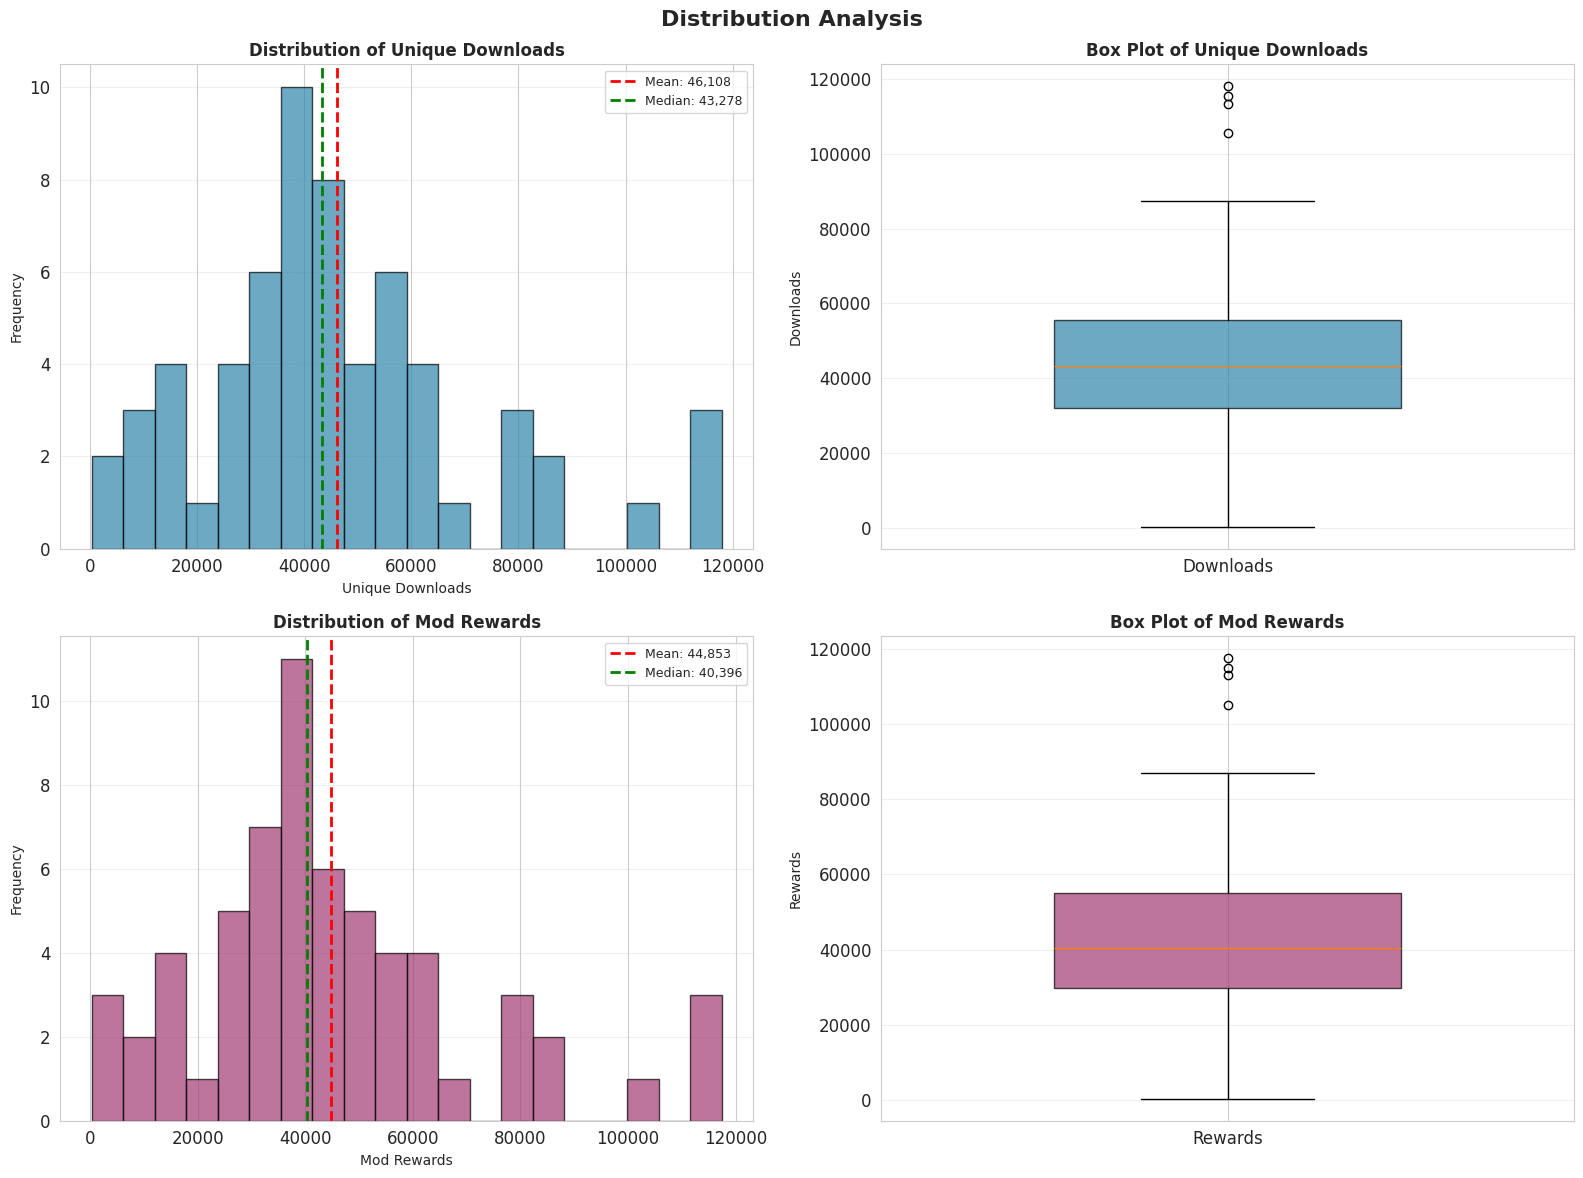


Visualization saved to: analysis_output/distribution_analysis.png


In [34]:
# Create distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distribution Analysis', fontsize=16, fontweight='bold')

# Plot 1: Histogram of downloads
ax1 = axes[0, 0]
ax1.hist(df['Unique Downloads'], bins=20, color='#2E86AB', alpha=0.7, 
         edgecolor='black', linewidth=1)
ax1.axvline(df['Unique Downloads'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {mean_downloads:,.0f}')
ax1.axvline(df['Unique Downloads'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {median_downloads:,.0f}')
ax1.set_title('Distribution of Unique Downloads', fontsize=12, fontweight='bold')
ax1.set_xlabel('Unique Downloads', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Box plot of downloads
ax2 = axes[0, 1]
bp = ax2.boxplot([df['Unique Downloads']], labels=['Downloads'], 
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][0].set_alpha(0.7)
ax2.set_title('Box Plot of Unique Downloads', fontsize=12, fontweight='bold')
ax2.set_ylabel('Downloads', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Histogram of rewards
ax3 = axes[1, 0]
ax3.hist(df['Mod Rewards'], bins=20, color='#A23B72', alpha=0.7, 
         edgecolor='black', linewidth=1)
ax3.axvline(df['Mod Rewards'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {mean_rewards:,.0f}')
ax3.axvline(df['Mod Rewards'].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {median_rewards:,.0f}')
ax3.set_title('Distribution of Mod Rewards', fontsize=12, fontweight='bold')
ax3.set_xlabel('Mod Rewards', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Box plot of rewards
ax4 = axes[1, 1]
bp = ax4.boxplot([df['Mod Rewards']], labels=['Rewards'], 
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#A23B72')
bp['boxes'][0].set_alpha(0.7)
ax4.set_title('Box Plot of Mod Rewards', fontsize=12, fontweight='bold')
ax4.set_ylabel('Rewards', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{output_dir}/distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/distribution_analysis.png")

## 15. Cumulative Analysis

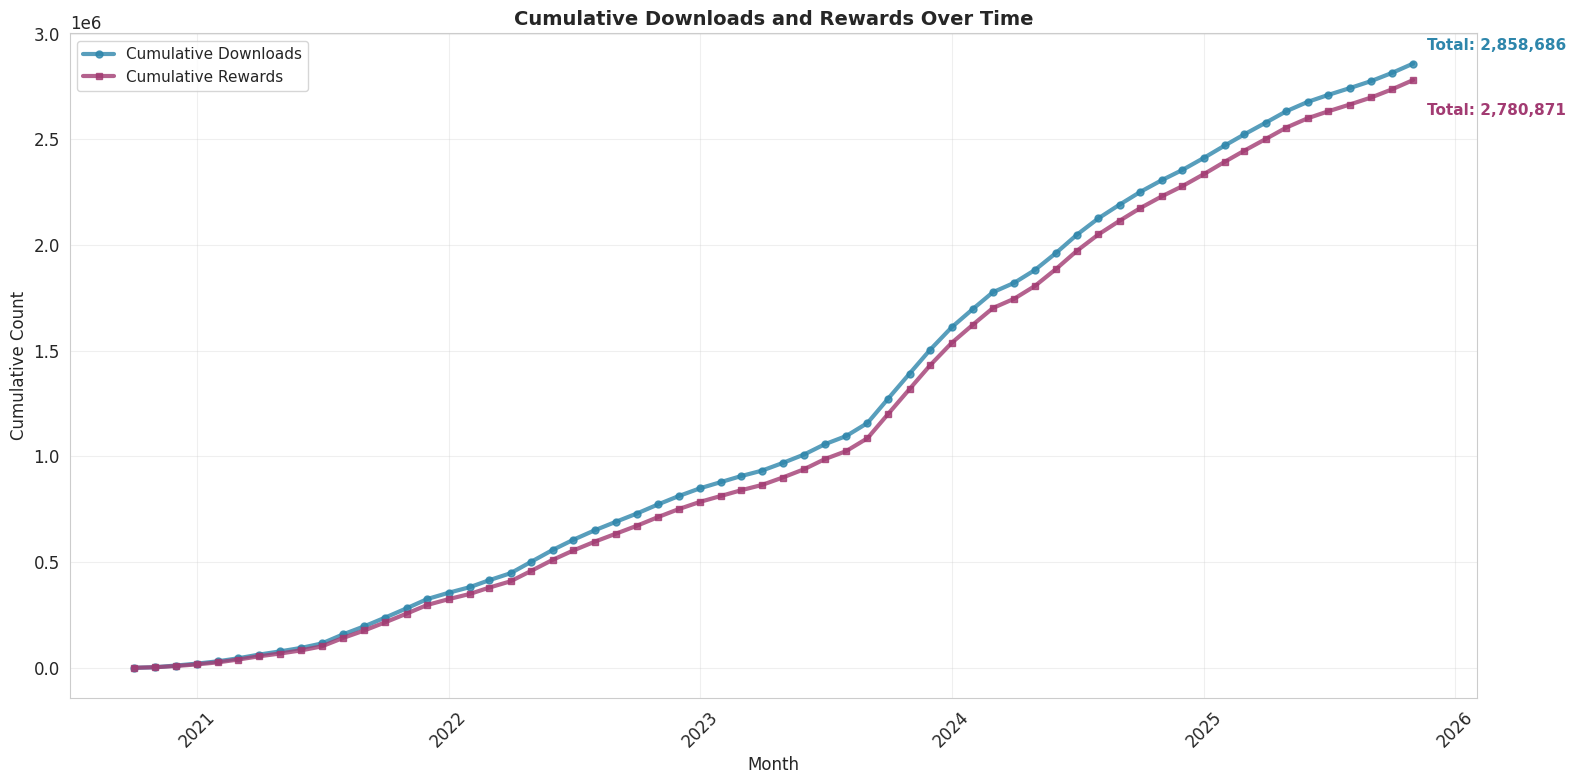


Visualization saved to: analysis_output/cumulative_analysis.png


In [35]:
# Create cumulative analysis
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df.index, df['Cumulative Downloads'], marker='o', linewidth=3, 
        markersize=5, label='Cumulative Downloads', color='#2E86AB', alpha=0.8)
ax.plot(df.index, df['Cumulative Rewards'], marker='s', linewidth=3, 
        markersize=5, label='Cumulative Rewards', color='#A23B72', alpha=0.8)

# Add annotations for key milestones
total_downloads_end = df['Cumulative Downloads'].iloc[-1]
total_rewards_end = df['Cumulative Rewards'].iloc[-1]

ax.annotate(f'Total: {total_downloads_end:,}', 
            xy=(df.index[-1], total_downloads_end), 
            xytext=(10, 10), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#2E86AB')
ax.annotate(f'Total: {total_rewards_end:,}', 
            xy=(df.index[-1], total_rewards_end), 
            xytext=(10, -25), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#A23B72')

ax.set_title('Cumulative Downloads and Rewards Over Time', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Cumulative Count', fontsize=12)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{output_dir}/cumulative_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to: {output_dir}/cumulative_analysis.png")

## 16. Top and Bottom Performing Months

In [36]:
# Top 5 months by downloads
top_downloads = df.nlargest(5, 'Unique Downloads')[['Unique Downloads', 'Mod Rewards']]
top_downloads['Month'] = top_downloads.index.strftime('%B %Y')
top_downloads = top_downloads[['Month', 'Unique Downloads', 'Mod Rewards']]

# Bottom 5 months by downloads
bottom_downloads = df.nsmallest(5, 'Unique Downloads')[['Unique Downloads', 'Mod Rewards']]
bottom_downloads['Month'] = bottom_downloads.index.strftime('%B %Y')
bottom_downloads = bottom_downloads[['Month', 'Unique Downloads', 'Mod Rewards']]

# Top 5 months by rewards
top_rewards = df.nlargest(5, 'Mod Rewards')[['Unique Downloads', 'Mod Rewards']]
top_rewards['Month'] = top_rewards.index.strftime('%B %Y')
top_rewards = top_rewards[['Month', 'Unique Downloads', 'Mod Rewards']]

# Bottom 5 months by rewards
bottom_rewards = df.nsmallest(5, 'Mod Rewards')[['Unique Downloads', 'Mod Rewards']]
bottom_rewards['Month'] = bottom_rewards.index.strftime('%B %Y')
bottom_rewards = bottom_rewards[['Month', 'Unique Downloads', 'Mod Rewards']]

print("\n" + "="*70)
print("TOP 5 MONTHS BY UNIQUE DOWNLOADS")
print("="*70)
print(top_downloads.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 MONTHS BY UNIQUE DOWNLOADS")
print("="*70)
print(bottom_downloads.to_string(index=False))

print("\n" + "="*70)
print("TOP 5 MONTHS BY MOD REWARDS")
print("="*70)
print(top_rewards.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 MONTHS BY MOD REWARDS")
print("="*70)
print(bottom_rewards.to_string(index=False))


TOP 5 MONTHS BY UNIQUE DOWNLOADS
        Month  Unique Downloads  Mod Rewards
November 2023            117985       117424
 October 2023            115350       114934
December 2023            113373       112906
 January 2024            105503       104948
February 2024             87359        86869

BOTTOM 5 MONTHS BY UNIQUE DOWNLOADS
        Month  Unique Downloads  Mod Rewards
 October 2020               327          327
November 2020              2780         2780
December 2020              7896         5609
 January 2021              9166         7898
February 2021             11253         9865

TOP 5 MONTHS BY MOD REWARDS
        Month  Unique Downloads  Mod Rewards
November 2023            117985       117424
 October 2023            115350       114934
December 2023            113373       112906
 January 2024            105503       104948
February 2024             87359        86869

BOTTOM 5 MONTHS BY MOD REWARDS
        Month  Unique Downloads  Mod Rewards
 October 2020

## 17. Save Processed Data to Output Directory

In [37]:
# Save cleaned DataFrame to CSV
output_csv = f'{output_dir}/nexusmods_rewards_processed.csv'
df.to_csv(output_csv)

# Save with growth rates and moving averages
df_with_analysis = df.copy()
df_with_analysis['Month'] = df_with_analysis.index.strftime('%Y-%m-%d')
df_with_analysis = df_with_analysis.reset_index(drop=True)
df_with_analysis.to_csv(f'{output_dir}/nexusmods_rewards_full_analysis.csv', index=False)

# Save forecast data
forecast_df = pd.DataFrame({
    'Month': dl_forecast_dates.strftime('%Y-%m-%d'),
    'Downloads Forecast': dl_forecast_values.values,
    'Downloads Lower CI': dl_confidence['lower'].values,
    'Downloads Upper CI': dl_confidence['upper'].values,
    'Rewards Forecast': rw_forecast_values.values,
    'Rewards Lower CI': rw_confidence['lower'].values,
    'Rewards Upper CI': rw_confidence['upper'].values
})
forecast_df.to_csv(f'{output_dir}/nexusmods_forecast.csv', index=False)

# Save monthly averages (seasonal patterns)
monthly_avg.to_csv(f'{output_dir}/nexusmods_monthly_averages.csv')

print(f"\nAll data files saved to: {output_dir}/")
print(f"  - nexusmods_rewards_processed.csv")
print(f"  - nexusmods_rewards_full_analysis.csv")
print(f"  - nexusmods_forecast.csv")
print(f"  - nexusmods_monthly_averages.csv")
print(f"\nTotal records: {len(df)}")
print(f"Date range: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")


All data files saved to: analysis_output/
  - nexusmods_rewards_processed.csv
  - nexusmods_rewards_full_analysis.csv
  - nexusmods_forecast.csv
  - nexusmods_monthly_averages.csv

Total records: 62
Date range: October 2020 to November 2025


## 18. Final Summary Report

In [ ]:
# Find best and worst performing months on average
best_month_downloads = monthly_avg.loc[monthly_avg['Unique Downloads'].idxmax()]
worst_month_downloads = monthly_avg.loc[monthly_avg['Unique Downloads'].idxmin()]
best_month_rewards = monthly_avg.loc[monthly_avg['Mod Rewards'].idxmax()]
worst_month_rewards = monthly_avg.loc[monthly_avg['Mod Rewards'].idxmin()]

# Generate final summary report
print("\n" + "="*80)
print("NEXUS MODS REWARDS ANALYSIS")
print("="*80)
print(f"\nAnalysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nDATA OVERVIEW:")
print(f"  - Period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"  - Total Months: {len(df)}")
print(f"  - Data Points: {len(df) * 2} (downloads + rewards)")
print(f"  - Years Covered: {len(df['Year'].unique())}")

print(f"\nKEY METRICS:")
print(f"  - Total Mod Rewards: {total_rewards:,} points")
print(f"  - Total Unique Downloads: {total_downloads:,}")
print(f"  - Average Monthly Downloads: {mean_downloads:,.2f}")
print(f"  - Average Monthly Rewards: {mean_rewards:,.2f}")
print(f"  - Median Monthly Downloads: {median_downloads:,.2f}")
print(f"  - Median Monthly Rewards: {median_rewards:,.2f}")

print(f"\nVOLATILITY ANALYSIS:")
print(f"  - Downloads Std Dev: {std_downloads:,.2f}")
print(f"  - Downloads CV: {(std_downloads/mean_downloads)*100:.2f}%")
print(f"  - Rewards Std Dev: {std_rewards:,.2f}")
print(f"  - Rewards CV: {(std_rewards/mean_rewards)*100:.2f}%")

print(f"\nPEAK PERFORMANCE:")
print(f"  - Highest Downloads: {peak_downloads_value:,} ({peak_downloads_month.strftime('%B %Y')})")
print(f"  - Highest Rewards: {peak_rewards_value:,} ({peak_rewards_month.strftime('%B %Y')})")
print(f"  - Lowest Downloads: {lowest_downloads_value:,} ({lowest_downloads_month.strftime('%B %Y')})")

print(f"\nGROWTH ANALYSIS:")
print(f"  - Average Monthly Growth (Downloads): {avg_monthly_growth_downloads:.2f}%")
print(f"  - Average Monthly Growth (Rewards): {avg_monthly_growth_rewards:.2f}%")
print(f"  - Downloads-Rewards Correlation: {correlation:.4f}")
print(f"  - Correlation Strength: {'Very Strong' if abs(correlation) > 0.8 else 'Strong' if abs(correlation) > 0.6 else 'Moderate' if abs(correlation) > 0.4 else 'Weak'}")

print(f"\nOUTLIER ANALYSIS:")
print(f"  - Downloads Outliers Detected: {df['Downloads Outlier'].sum()} months")
print(f"  - Rewards Outliers Detected: {df['Rewards Outlier'].sum()} months")
print(f"  - Outlier Detection Methods: IQR (1.5x) and Z-score (3.0)")

print(f"\nFORECASTING:")
print(f"  - Forecast Period: {forecast_periods} months")
print(f"  - Forecast Methods: Linear Trend and 3-Month Moving Average")
print(f"  - Confidence Interval: 95%")
print(f"  - Forecast Start: {df.index[-1].strftime('%B %Y')}")

print(f"\nSEASONAL INSIGHTS:")
print(f"  - Best Month for Downloads: {best_month_downloads['Month_Name']} (avg: {best_month_downloads['Unique Downloads']:,.0f})")
print(f"  - Worst Month for Downloads: {worst_month_downloads['Month_Name']} (avg: {worst_month_downloads['Unique Downloads']:,.0f})")
print(f"  - Best Month for Rewards: {best_month_rewards['Month_Name']} (avg: {best_month_rewards['Mod Rewards']:,.0f})")
print(f"  - Worst Month for Rewards: {worst_month_rewards['Month_Name']} (avg: {worst_month_rewards['Mod Rewards']:,.0f})")

print(f"\nOUTPUT FILES GENERATED:")
print(f"  All files saved to: {output_dir}/")
print(f"  \nCSV Files:")
print(f"    1. nexusmods_rewards_processed.csv - Cleaned data")
print(f"    2. nexusmods_rewards_full_analysis.csv - Data with all analysis columns")
print(f"    3. nexusmods_forecast.csv - Forecast data with confidence intervals")
print(f"    4. nexusmods_monthly_averages.csv - Monthly averages (seasonal patterns)")

print(f"  \nPNG Visualizations:")
print(f"    1. moving_averages_with_outliers.png - Time series with outliers highlighted")
print(f"    2. forecast_analysis.png - 6-month forecast with confidence intervals")
print(f"    3. growth_rates.png - Monthly growth rate analysis")
print(f"    4. correlation_analysis.png - Downloads vs Rewards correlation")
print(f"    5. seasonal_patterns.png - Seasonal patterns analysis")
print(f"    6. year_over_year.png - Year-over-year comparison")
print(f"    7. distribution_analysis.png - Distribution analysis with box plots")
print(f"    8. cumulative_analysis.png - Cumulative totals over time")

print("\n" + "="*80)


NEXUS MODS REWARDS ANALYSIS - COMPREHENSIVE FINAL REPORT

Analysis Date: 2026-01-04 20:58:49

DATA OVERVIEW:
  - Period: October 2020 to November 2025
  - Total Months: 62
  - Data Points: 124 (downloads + rewards)
  - Years Covered: 6

KEY METRICS:
  - Total Mod Rewards: 2,780,871 points
  - Total Unique Downloads: 2,858,686
  - Average Monthly Downloads: 46,107.84
  - Average Monthly Rewards: 44,852.76
  - Median Monthly Downloads: 43,277.50
  - Median Monthly Rewards: 40,396.00

VOLATILITY ANALYSIS:
  - Downloads Std Dev: 26,173.13
  - Downloads CV: 56.77%
  - Rewards Std Dev: 26,513.89
  - Rewards CV: 59.11%

PEAK PERFORMANCE:
  - Highest Downloads: 117,985 (November 2023)
  - Highest Rewards: 117,424 (November 2023)
  - Lowest Downloads: 327 (October 2020)

GROWTH ANALYSIS:
  - Average Monthly Growth (Downloads): 20.87%
  - Average Monthly Growth (Rewards): 20.26%
  - Downloads-Rewards Correlation: 0.9990
  - Correlation Strength: Very Strong

OUTLIER ANALYSIS:
  - Downloads Outl